In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import os
import pathlib
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls "/content/drive/My Drive/Colab Notebooks/Interior-Exterior Scene Classification"

test  train  val


In [5]:
base_dir = '/content/drive/My Drive/Colab Notebooks/Interior-Exterior Scene Classification'

num_exterior_images = len(os.listdir(base_dir + '/train/Exterior'))
num_interior_images = len(os.listdir(base_dir + '/train/Interior'))

num_exterior_images, num_interior_images

(800, 800)

In [6]:
data_dir = pathlib.Path(base_dir + "/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['Exterior' 'Interior']


In [7]:
def random_img(dirpath, target_class):
  directory = dirpath + "/" + target_class
  random_img = random.sample(os.listdir(directory), 1)

  img = mpimg.imread(directory + "/" + random_img[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')
  print(f"Image shape: {img.shape}")

  return img

Image shape: (480, 854, 3)


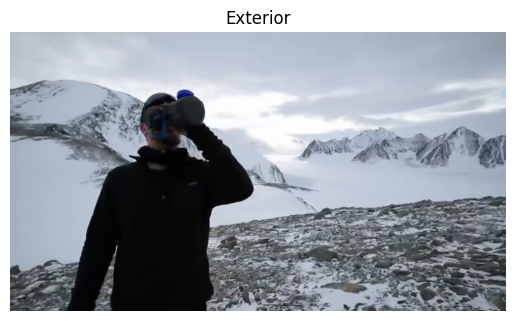

In [8]:
img = random_img(base_dir + "/train", class_names[0])

# DATA

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_dir = base_dir + "/train"
test_dir = base_dir + "/test"
val_dir = base_dir + "/val"

In [11]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               shuffle=True)
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224,224),
                                             class_mode="binary"
                                             )
val_data = val_datagen.flow_from_directory(val_dir,
                                           batch_size=32,
                                           target_size=(224,224),
                                           class_mode="binary"
                                           )

Found 1600 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 202 images belonging to 2 classes.


In [12]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

baseline_model_loss = baseline_model.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    validation_steps=len(val_data)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5887 - loss: 0.6691

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 348s 7s/step - accuracy: 0.5898 - loss: 0.6680 - val_accuracy: 0.6931 - val_loss: 0.5630
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 638ms/step - accuracy: 0.7370 - loss: 0.5213 - val_accuracy: 0.7574 - val_loss: 0.5150
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 627ms/step - accuracy: 0.7706 - loss: 0.4781 - val_accuracy: 0.7921 - val_loss: 0.4890
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 665ms/step - accuracy: 0.7538 - loss: 0.4950 - val_accuracy: 0.7871 - val_loss: 0.4916
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 644ms/step - accuracy: 0.7870 - loss: 0.4455 - val_accuracy: 0.7673 - val_loss: 0.5139


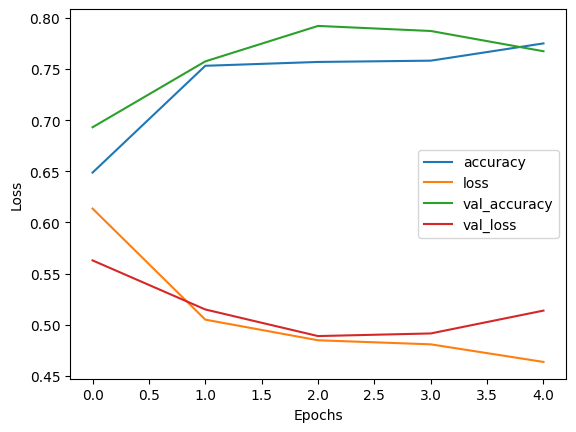

In [13]:
pd.DataFrame(baseline_model_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [14]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

model_loss_1 = model_1.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    validation_steps=len(val_data)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 634ms/step - accuracy: 0.5482 - loss: 0.6746 - val_accuracy: 0.7772 - val_loss: 0.5169
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 624ms/step - accuracy: 0.7419 - loss: 0.5248 - val_accuracy: 0.7624 - val_loss: 0.5254
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 624ms/step - accuracy: 0.7484 - loss: 0.5086 - val_accuracy: 0.7574 - val_loss: 0.4890
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 648ms/step - accuracy: 0.7874 - loss: 0.4593 - val_accuracy: 0.7624 - val_loss: 0.4827
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 624ms/step - accuracy: 0.8034 - loss: 0.4334 - val_accuracy: 0.8069 - val_loss: 0.4175


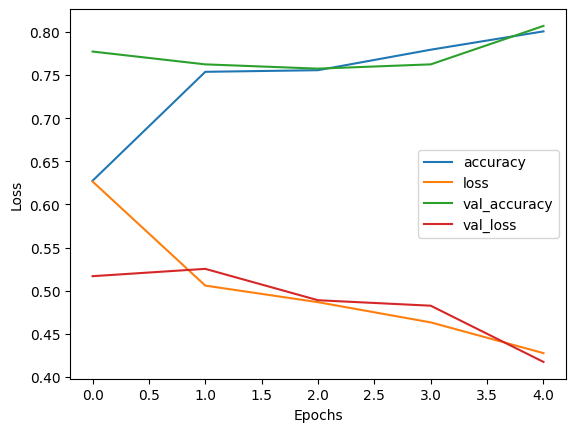

In [15]:
pd.DataFrame(model_loss_1.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [16]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.Conv2D(filters=10, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              metrics=['accuracy'])

model_loss_3 = model_3.fit(
    train_data,
    epochs=10,
    steps_per_epoch=len(train_data),
    validation_data=val_data,
    validation_steps=len(val_data)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 653ms/step - accuracy: 0.5550 - loss: 0.6760 - val_accuracy: 0.7475 - val_loss: 0.5767
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 636ms/step - accuracy: 0.7290 - loss: 0.5427 - val_accuracy: 0.7921 - val_loss: 0.5046
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 640ms/step - accuracy: 0.7582 - loss: 0.4974 - val_accuracy: 0.7574 - val_loss: 0.5297
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 662ms/step - accuracy: 0.7708 - loss: 0.4838 - val_accuracy: 0.7525 - val_loss: 0.5226
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 648ms/step - accuracy: 0.7874 - loss: 0.4730 - val_accuracy: 0.7921 - val_loss: 0.4950
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 688ms/step - accuracy: 0.7785 - loss: 0.4550 - val_accuracy: 0.8069 - val_loss: 0.4800
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 634ms/step - accuracy: 0.8055 - loss: 0.4106 - val_accuracy: 0.7921 - val_loss: 0.4751
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 629ms/step - accuracy: 0.7950 - loss: 0.4279 - val_accu

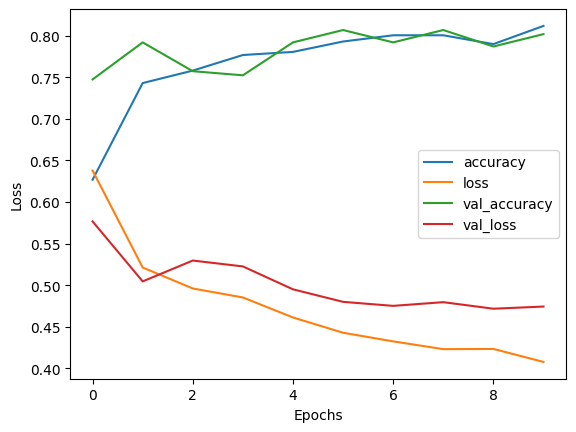

In [17]:
pd.DataFrame(model_loss_3.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [18]:
model_1.save("model_1.h5")

In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
model = load_model("model_1.h5")

In [22]:
img_path = "home_office.jpg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array /= 255.0
img_array = np.expand_dims(img_array, axis=0)


In [23]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


In [24]:
predicted_class = "Exterior" if prediction[0][0] > 0.5 else "Interior"

In [26]:
print(train_data.class_indices)

{'Exterior': 0, 'Interior': 1}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


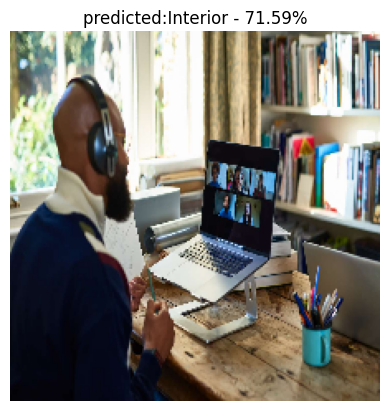

In [35]:
class_dict = train_data.class_indices
class_labels = list(class_dict.keys())
class_mapping = {v: k for k, v in class_dict.items()}

prob = model.predict(img_array)[0][0]
predicted_label = class_mapping[int(prob > 0.5)]

plt.imshow(img)
plt.title(f"predicted:{predicted_label} - {prob*100:.2f}%")
plt.axis("off")
plt.show()
